# 개포동 빌라 실거래가 분석

순서 : 데이터 처리 → 피처 엔지니어링 → OLS / 건물 고정효과 모델 → 트렌드 시각화

* 출처 : 국토교통부 실거래가공개시스템 자료제공 (필터: 연립/60제곱미터 이하/개포동)
* 법인 거래 제외 (개인 매도, 개인 매수만 확인)
* 중개거래만 포함 (직거래 제외)

## 0. 설정

In [1]:
import datetime as dt
import polars as pl
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (macOS: AppleGothic, Linux: NanumGothic 등)
import matplotlib
import platform
if platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='DejaVu Sans')  # 한글 없을 경우 fallback
matplotlib.rc('axes', unicode_minus=False)

# ★ 데이터 경로만 여기서 수정
DATA_PATH = "data.csv"
BASE_YEAR = 2024
BASE_MONTH = 3  # 시간 인덱스 0 기준월
CURRENT_YEAR = dt.datetime.now().year

## 1. 데이터 로드 및 전처리

In [2]:
def load_and_preprocess(path: str) -> pl.DataFrame:
    df = pl.read_csv(path)

    df_med = (
        df.filter(pl.col("거래유형") == "중개거래")
        .with_columns(
            pl.col("거래금액(만원)").str.replace_all(",", "").cast(pl.Int64).alias("price")
        )
        .with_columns(
            (pl.col("본번").cast(pl.Utf8) + "-" + pl.col("부번").cast(pl.Utf8)).alias("building_id")
        )
        .with_columns(
            (
                (pl.col("계약년월").cast(pl.Utf8).str.slice(0, 4).cast(pl.Int64) - BASE_YEAR) * 12
                + pl.col("계약년월").cast(pl.Utf8).str.slice(4, 2).cast(pl.Int64)
                - BASE_MONTH
            ).alias("time_idx")
        )
        .with_columns(
            (pl.col("계약년월").cast(pl.Utf8).str.slice(0, 4) + "-"
             + pl.col("계약년월").cast(pl.Utf8).str.slice(4, 2)).alias("ym")
        )
        .with_columns(
            (CURRENT_YEAR - pl.col("건축년도")).alias("age"),
            (pl.col("층") < 0).cast(pl.Int8).alias("is_basement")
        )
        .rename({"전용면적(㎡)": "area", "대지권면적(㎡)": "land_area", "층": "floor"})
        # 개인↔개인 거래만 (법인 대량매입/매각 노이즈 제거)
        .filter((pl.col("매도자") == "개인") & (pl.col("매수자") == "개인"))
        # 전용면적 60제곱 이하
        .filter(pl.col("area") <= 60)
    )
    return df_med

df = load_and_preprocess(DATA_PATH)

print(f"전체 → 중개거래 + 개인↔개인: {len(df)}건")
print(f"기간: {df['ym'].min()} ~ {df['ym'].max()}")
print(f"price 중위값: {df['price'].median():,.0f} 만원")

전체 → 중개거래 + 개인↔개인: 249건
기간: 2024-03 ~ 2026-04
price 중위값: 52,500 만원


## 2. 기초 분포 확인

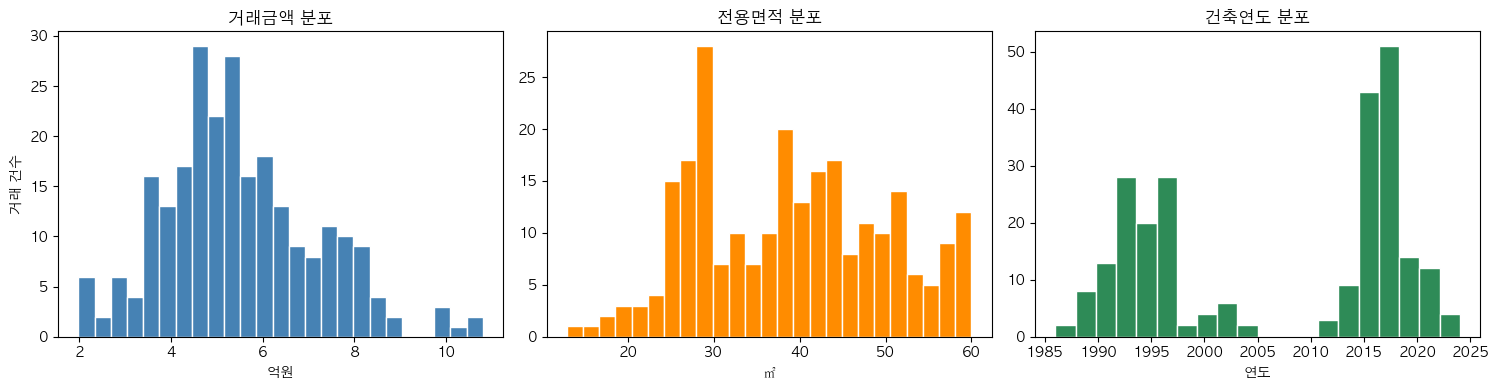

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 거래금액 분포
axes[0].hist(df["price"].to_numpy() / 10000, bins=25, color="steelblue", edgecolor="white")
axes[0].set_title("거래금액 분포")
axes[0].set_xlabel("억원")
axes[0].set_ylabel("거래 건수")

# 전용면적 분포
axes[1].hist(df["area"].to_numpy(), bins=25, color="darkorange", edgecolor="white")
axes[1].set_title("전용면적 분포")
axes[1].set_xlabel("㎡")

# 건축연도 분포
axes[2].hist((CURRENT_YEAR - df["age"]).to_numpy(), bins=20, color="seagreen", edgecolor="white")
axes[2].set_title("건축연도 분포")
axes[2].set_xlabel("연도")

plt.tight_layout()
plt.show()

## 3. 월별 중위 거래가 트렌드

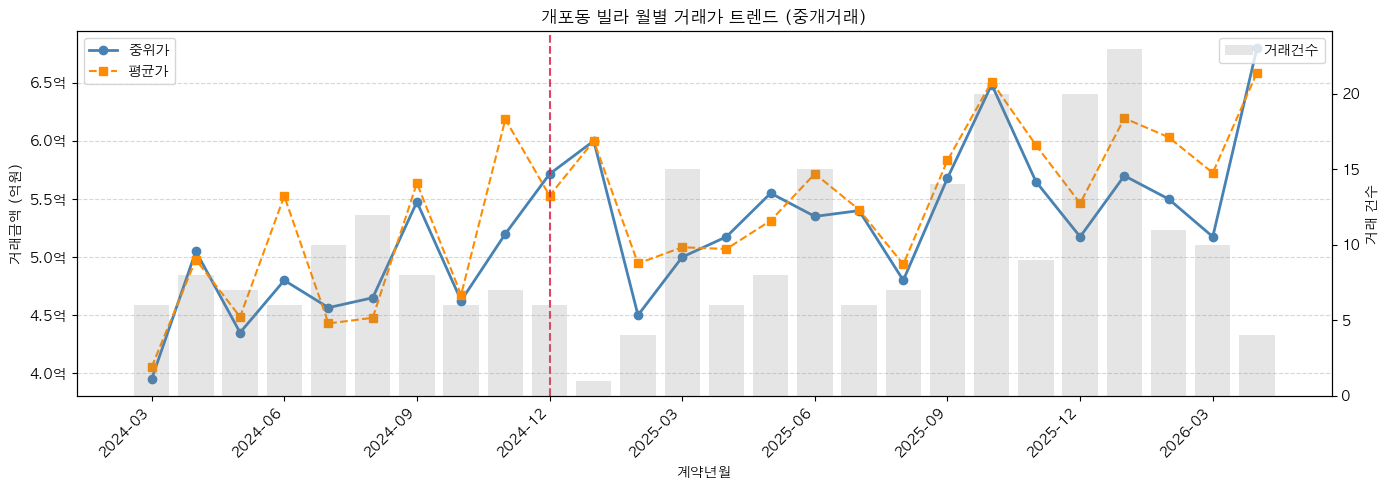

In [4]:
monthly = (
    df.group_by("ym").agg([
        pl.col("price").median().alias("median_price"),
        pl.col("price").mean().alias("mean_price"),
        pl.col("price").count().alias("n")
    ]).sort("ym")
)

ym_labels = monthly["ym"].to_list()
med = monthly["median_price"].to_numpy() / 10000
avg = monthly["mean_price"].to_numpy() / 10000
n   = monthly["n"].to_numpy()

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(ym_labels, med, marker="o", color="steelblue", linewidth=2, label="중위가")
ax1.plot(ym_labels, avg, marker="s", color="darkorange", linewidth=1.5, linestyle="--", label="평균가")
ax1.set_ylabel("거래금액 (억원)")
ax1.set_xlabel("계약년월")
ax1.set_title("개포동 빌라 월별 거래가 트렌드 (중개거래)")
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f억'))
ax1.grid(axis='y', linestyle='--', alpha=0.5)

quarterly_idx = [i for i, ym in enumerate(ym_labels) if ym.endswith(("-03", "-06", "-09", "-12"))]
ax1.set_xticks(quarterly_idx)
ax1.set_xticklabels([ym_labels[i] for i in quarterly_idx], rotation=45, ha="right")
ax1.legend(loc="upper left")

if "2024-12" in ym_labels:
    ax1.axvline(x=ym_labels.index("2024-12"), color="crimson", linestyle="--", linewidth=1.5, alpha=0.8, label="2024-12")

# 거래 건수 막대
ax2 = ax1.twinx()
ax2.bar(ym_labels, n, alpha=0.2, color="gray", label="거래건수")
ax2.set_ylabel("거래 건수")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

## 4. 면적 보정 트렌드 (㎡당 가격)

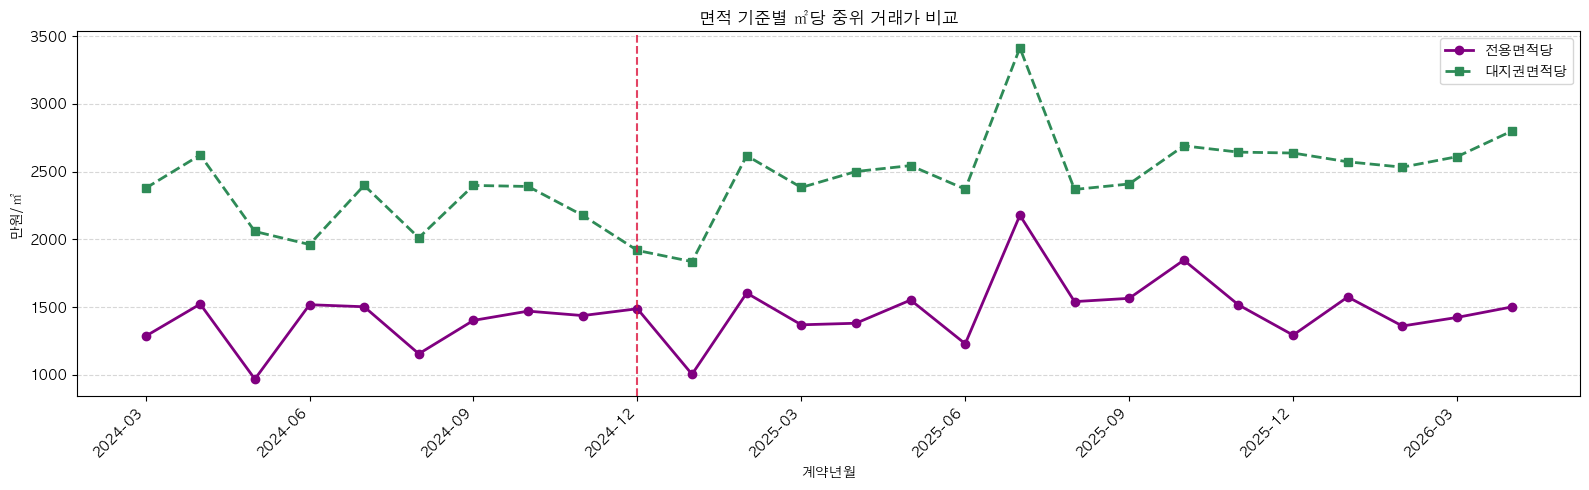

In [5]:
df_ppm = df.with_columns([
    (pl.col("price") / pl.col("area")).alias("price_per_area"),
    (pl.col("price") / pl.col("land_area")).alias("price_per_land")
])

monthly_ppm = (
    df_ppm.group_by("ym").agg([
        pl.col("price_per_area").median().alias("med_area"),
        pl.col("price_per_land").median().alias("med_land")
    ]).sort("ym")
)

ym_list = monthly_ppm["ym"].to_list()
quarterly_idx = [i for i, ym in enumerate(ym_list) if ym.endswith(("-03", "-06", "-09", "-12"))]
quarterly_labels = [ym_list[i] for i in quarterly_idx]

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(ym_list, monthly_ppm["med_area"].to_numpy(), marker="o", color="purple", linewidth=2, label="전용면적당")
ax.plot(ym_list, monthly_ppm["med_land"].to_numpy(), marker="s", color="seagreen", linewidth=2, linestyle="--", label="대지권면적당")
ax.set_title("면적 기준별 ㎡당 중위 거래가 비교")
ax.set_ylabel("만원/㎡")
ax.set_xlabel("계약년월")
ax.set_xticks(quarterly_idx)
ax.set_xticklabels(quarterly_labels, rotation=45, ha="right")
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend()

if "2024-12" in ym_list:
    ax.axvline(x=ym_list.index("2024-12"), color="crimson", linestyle="--", linewidth=1.5, alpha=0.8, label="2024-12")

plt.tight_layout()
plt.show()

## 5. 모델 1: 기본 OLS

In [6]:
df_m1 = df.select(["price","area","land_area","floor","age","is_basement","time_idx","building_id"]).to_pandas()

m1 = smf.ols("price ~ area + land_area + floor + age + is_basement + time_idx", data=df_m1).fit()

print(f"=== 모델 1: 기본 OLS (n={len(df_m1)}) ===")
print(f"R²={m1.rsquared:.4f}  Adj R²={m1.rsquared_adj:.4f}")
print()

summary = pl.DataFrame({
    "변수": m1.params.index.tolist(),
    "계수": m1.params.values.round(1).tolist(),
    "p-value": m1.pvalues.values.round(4).tolist(),
    "유의": ["***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "" for p in m1.pvalues.values]
})
print(summary)

print(f"""
해석:
  전용면적 +1㎡  → 가격 +{m1.params['area']:,.0f} 만원
  건축연도 +1년  → 가격 {m1.params['age']:,.0f} 만원
  지하층        → 가격 {m1.params['is_basement']:,.0f} 만원
  월 추세       → 가격 +{m1.params['time_idx']:,.0f} 만원/월
""")

=== 모델 1: 기본 OLS (n=249) ===
R²=0.6310  Adj R²=0.6218

shape: (7, 4)
┌─────────────┬──────────┬─────────┬──────┐
│ 변수        ┆ 계수     ┆ p-value ┆ 유의 │
│ ---         ┆ ---      ┆ ---     ┆ ---  │
│ str         ┆ f64      ┆ f64     ┆ str  │
╞═════════════╪══════════╪═════════╪══════╡
│ Intercept   ┆ 23483.6  ┆ 0.0     ┆ ***  │
│ area        ┆ 819.5    ┆ 0.0     ┆ ***  │
│ land_area   ┆ 243.5    ┆ 0.0001  ┆ ***  │
│ floor       ┆ -258.9   ┆ 0.6359  ┆      │
│ age         ┆ -611.9   ┆ 0.0     ┆ ***  │
│ is_basement ┆ -15542.9 ┆ 0.0     ┆ ***  │
│ time_idx    ┆ 550.3    ┆ 0.0     ┆ ***  │
└─────────────┴──────────┴─────────┴──────┘

해석:
  전용면적 +1㎡  → 가격 +820 만원
  건축연도 +1년  → 가격 -612 만원
  지하층        → 가격 -15,543 만원
  월 추세       → 가격 +550 만원/월



## 6. 모델 2: 건물 고정효과 (반복거래 n회 이상)

* 몇층인지는 가격에 영향이 없으므로(`floor`의 pvalue > 0.05) 건물에 ID를 부여한 random intercept model 채택
* 물론 반지하 여부는 가격에 큰 영향을 미치므로 해당 조건에 부합하는 레코드는 제외

In [7]:
n = 3
df_m2 = (
    df
    .select(["price","area","land_area","floor","age","is_basement","time_idx","building_id"])
    .filter(pl.col("is_basement") == 0)
    .to_pandas()
)
freq = df_m2["building_id"].value_counts()
buildings_freq = freq[freq >= n].index.tolist()
df_fe = df_m2[df_m2["building_id"].isin(buildings_freq)].copy()

m2 = smf.ols("price ~ area + land_area + floor + age + is_basement + time_idx + C(building_id)", data=df_fe).fit()

coef_t = m2.params["time_idx"]
pval_t = m2.pvalues["time_idx"]
median_p = df_m2["price"].median()

print(f"=== 모델 2: 건물 고정효과 (n={len(df_fe)}) ===")
print(f"R²={m2.rsquared:.4f}  Adj R²={m2.rsquared_adj:.4f}")
print(f"""
time_idx 계수 : {coef_t:,.0f} 만원/월
p-value       : {pval_t:.4f}
월 상승률     : {coef_t/median_p*100:.2f}%
연환산 상승률 : {((1 + coef_t/median_p)**12 - 1)*100:.1f}%
""")

=== 모델 2: 건물 고정효과 (n=118) ===
R²=0.8633  Adj R²=0.8072

time_idx 계수 : 510 만원/월
p-value       : 0.0000
월 상승률     : 0.94%
연환산 상승률 : 11.9%



## 7. 모델 적합값 vs 실제값 시각화

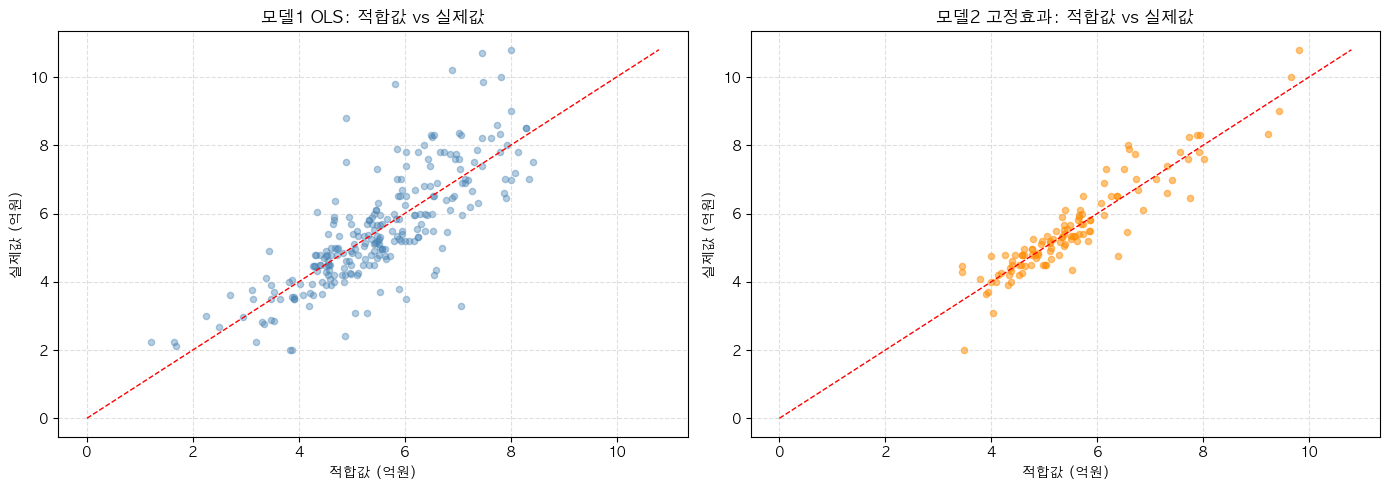

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 모델 1 잔차
fitted1 = m1.fittedvalues
actual1 = df_m1["price"]
axes[0].scatter(fitted1 / 10000, actual1 / 10000, alpha=0.4, color="steelblue", s=20)
lim = max(fitted1.max(), actual1.max()) / 10000
axes[0].plot([0, lim], [0, lim], "r--", linewidth=1)
axes[0].set_title("모델1 OLS: 적합값 vs 실제값")
axes[0].set_xlabel("적합값 (억원)")
axes[0].set_ylabel("실제값 (억원)")
axes[0].grid(linestyle='--', alpha=0.4)

# 모델 2 잔차
fitted2 = m2.fittedvalues
actual2 = df_fe["price"]
axes[1].scatter(fitted2 / 10000, actual2 / 10000, alpha=0.5, color="darkorange", s=20)
lim2 = max(fitted2.max(), actual2.max()) / 10000
axes[1].plot([0, lim2], [0, lim2], "r--", linewidth=1)
axes[1].set_title("모델2 고정효과: 적합값 vs 실제값")
axes[1].set_xlabel("적합값 (억원)")
axes[1].set_ylabel("실제값 (억원)")
axes[1].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [9]:
target = (
    df.filter((pl.col("건물명") == "개포비버리하임") & (pl.col("ym") == "2024-12"))
    .select(["건물명", "ym", "price", "area", "land_area", "floor", "age", "is_basement", "time_idx"])
    .to_pandas()
)
base_cols = ["area", "land_area", "floor", "age", "is_basement", "time_idx"]
yhat = (
    m2.params["Intercept"]
    + sum(m2.params[c] * target[c] for c in base_cols)
)
residual = yhat - target["price"]
print(f"예측 : {yhat[0].item() / 10000:.2f}억")

예측 : 6.44억


## 8. 시간 추세 회귀선 오버레이

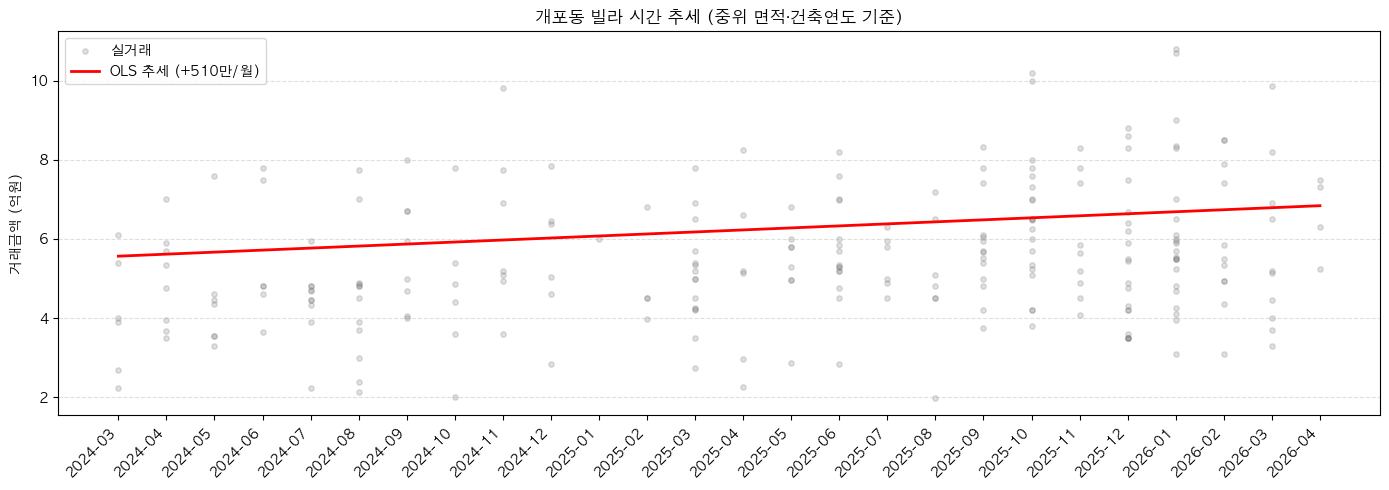

In [10]:
# OLS 모델의 time_idx 추세를 중위 면적 기준으로 시각화
med_area = df_m1["area"].median()
med_land = df_m1["land_area"].median()
med_floor = df_m1["floor"].median()
med_age = df_m1["age"].median()

t_range = np.arange(df_m1["time_idx"].min(), df_m1["time_idx"].max() + 1)
pred_price = (
    m2.params["Intercept"]
    + m2.params["area"] * med_area
    + m2.params["land_area"] * med_land
    + m2.params["floor"] * med_floor
    + m2.params["age"] * med_age
    + m2.params["is_basement"] * 0
    + m2.params["time_idx"] * t_range
)

# ym 라벨 매핑
ym_map = df.select(["time_idx","ym"]).unique().sort("time_idx").to_pandas()
ym_map = dict(zip(ym_map["time_idx"], ym_map["ym"]))
t_labels = [ym_map.get(t, str(t)) for t in t_range]

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(df_m1["time_idx"], df_m1["price"] / 10000, alpha=0.25, color="gray", s=15, label="실거래")
ax.plot(t_range, pred_price / 10000, color="red", linewidth=2, label=f"OLS 추세 (+{round(m2.params['time_idx'])}만/월)")
ax.set_xticks(t_range)
ax.set_xticklabels(t_labels, rotation=45, ha='right')
ax.set_title("개포동 빌라 시간 추세 (중위 면적·건축연도 기준)")
ax.set_ylabel("거래금액 (억원)")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()